# `weighted_corr_2d` Tutorial

This notebook demonstrates the `weighted_corr_2d` function across a range of replay scenarios — from idealized degenerate cases to more realistic curved and noisy trajectories and finally real data.

The function computes a **spatiotemporal correlation** from a 3D posterior probability matrix `(x, y, time)`, returning:
- `spatiotemporal_corr` — overall correlation strength and direction
- `x_traj`, `y_traj` — decoded trajectory over time
- `slope_x`, `slope_y` — rate of movement in each axis
- `mean_x`, `mean_y` — weighted center of mass

In [1]:
import numpy as np
import neuro_py as npy
from neuro_py.ensemble.replay import weighted_corr_2d
import matplotlib.pyplot as plt
import pandas as pd
import nelpy as nel
import matplotlib
import matplotlib.cm as mpl_cm
import matplotlib.colors as colors

## Helper: Simulation Functions

In [2]:
def simulate_degenerate_x(t_dim=20, x_fixed=5, noise=0.01):
    """All weight on a single x row — trajectory moves only in Y."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cy = k / (t_dim - 1) * (y_dim - 1)
        for j in range(y_dim):
            weights[x_fixed, j, k] = np.exp(-((j - cy) ** 2) / 4.0)
    weights[x_fixed] += rng.uniform(0, noise, (y_dim, t_dim))
    return weights


def simulate_degenerate_y(t_dim=20, y_fixed=5, noise=0.01):
    """All weight on a single y column — trajectory moves only in X."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        for i in range(x_dim):
            weights[i, y_fixed, k] = np.exp(-((i - cx) ** 2) / 4.0)
    weights[:, y_fixed, :] += rng.uniform(0, noise, (x_dim, t_dim))
    return weights


def simulate_no_movement(t_dim=20, noise=0.01):
    """Weight fixed at a single spatial location — no temporal drift."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    weights[5, 5, :] = 1.0
    weights += rng.uniform(0, noise, (x_dim, y_dim, t_dim))
    return weights


def simulate_both_axes(t_dim=20, noise=0.01):
    """Weight drifts diagonally — both X and Y move over time."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = k / (t_dim - 1) * (y_dim - 1)
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights


def simulate_curved(t_dim=20, noise=0.05):
    """Trajectory follows a curved arc (sine wave in Y)."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = 4.5 + 4.0 * np.sin(np.pi * k / (t_dim - 1))  # arc from 4.5 -> peak -> 4.5
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 2.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights


def simulate_noisy_linear(t_dim=20, noise=0.15):
    """Linear trajectory with substantial noise — realistic decode uncertainty."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = k / (t_dim - 1) * (x_dim - 1)
        cy = k / (t_dim - 1) * (y_dim - 1)
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights


def simulate_reverse(t_dim=20, noise=0.01):
    """Trajectory moves from high to low — tests sign of correlation."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        cx = (x_dim - 1) - k / (t_dim - 1) * (x_dim - 1)  # 9 -> 0
        cy = (y_dim - 1) - k / (t_dim - 1) * (y_dim - 1)  # 9 -> 0
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 4.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights


def simulate_fragmented(t_dim=20, noise=0.05):
    """Weight jumps between two spatial clusters — fragmented/ambiguous replay."""
    rng = np.random.default_rng(42)
    x_dim, y_dim = 10, 10
    weights = np.zeros((x_dim, y_dim, t_dim), dtype=np.float64)
    for k in range(t_dim):
        # Alternate between two clusters
        if k % 4 < 2:
            cx, cy = 2.0, 2.0
        else:
            cx, cy = 7.0, 7.0
        for i in range(x_dim):
            for j in range(y_dim):
                weights[i, j, k] = np.exp(-((i - cx) ** 2 + (j - cy) ** 2) / 2.0)
    weights += rng.uniform(0, noise, weights.shape)
    return weights

## Section 1 — Degenerate Cases

These scenarios test the edge cases where movement is confined to a single axis or absent entirely.

### 1a. Only Y-axis movement (degenerate X)

spatiotemporal corr : 0.8567  (expect ~0.857, y-axis only)
slope_x             : 3.668e-31  (expect ~0)
slope_y             : 0.4141  (expect ~0.41)


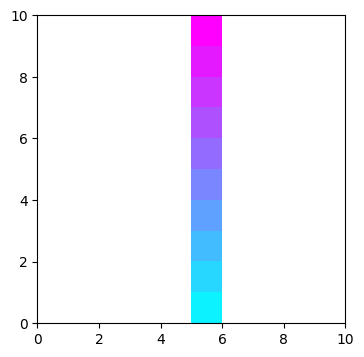

In [3]:
weights = simulate_degenerate_x()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (expect ~0.857, y-axis only)")
print(f"slope_x             : {slope_x:.3e}  (expect ~0)")
print(f"slope_y             : {slope_y:.4f}  (expect ~0.41)")

npy.plotting.plot_2d_replay(weights)
plt.show()

### 1b. Only X-axis movement (degenerate Y)

spatiotemporal corr : 0.8567  (expect ~0.857, x-axis only)
slope_x             : 0.4141  (expect ~0.41)
slope_y             : 9.090e-32  (expect ~0)


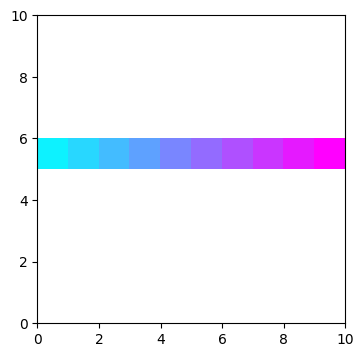

In [4]:
weights = simulate_degenerate_y()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (expect ~0.857, x-axis only)")
print(f"slope_x             : {slope_x:.4f}  (expect ~0.41)")
print(f"slope_y             : {slope_y:.3e}  (expect ~0)")

npy.plotting.plot_2d_replay(weights)
plt.show()

### 1c. No movement (neither axis)

spatiotemporal corr : 0.0098  (expect ~0, no signal)
slope_x             : 3.799e-03
slope_y             : 1.349e-03


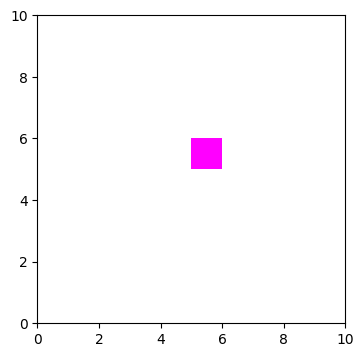

In [5]:
weights = simulate_no_movement()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (expect ~0, no signal)")
print(f"slope_x             : {slope_x:.3e}")
print(f"slope_y             : {slope_y:.3e}")

npy.plotting.plot_2d_replay(weights)
plt.show()

### 1d. Both axes moving (diagonal)

spatiotemporal corr : 0.8117  (expect ~0.81, both axes)
slope_x             : 0.4019
slope_y             : 0.4015


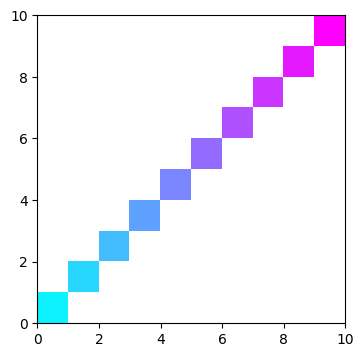

In [6]:
weights = simulate_both_axes()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (expect ~0.81, both axes)")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.4f}")

npy.plotting.plot_2d_replay(weights)
plt.show()

## Section 2 — Realistic Scenarios

Real decoded posteriors are rarely perfectly linear — they contain noise, curvature, and ambiguity. These scenarios test how `weighted_corr_2d` behaves under more naturalistic conditions.

### 2a. Curved trajectory (sine arc)

The center of mass follows a smooth arc in Y while sweeping across X. Since `weighted_corr_2d` fits a **linear** model, the correlation will be attenuated relative to a straight-line trajectory — the function captures the dominant linear trend.

spatiotemporal corr : 0.4520  (attenuated vs diagonal — nonlinear Y)
slope_x             : 0.3096  (X is still linear)
slope_y             : 0.0004  (near 0 — arc cancels out)


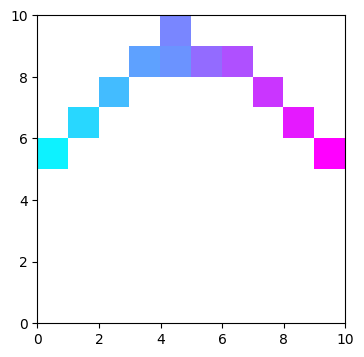

In [7]:
weights = simulate_curved()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (attenuated vs diagonal — nonlinear Y)")
print(f"slope_x             : {slope_x:.4f}  (X is still linear)")
print(f"slope_y             : {slope_y:.4f}  (near 0 — arc cancels out)")

npy.plotting.plot_2d_replay(weights)
plt.show()

### 2b. Noisy linear trajectory

A diagonal trajectory with substantial decode uncertainty. This is the most common real-data scenario — the signal is present but diluted by diffuse posteriors.

spatiotemporal corr : 0.4586  (lower than clean diagonal due to noise)
slope_x             : 0.2288
slope_y             : 0.2254


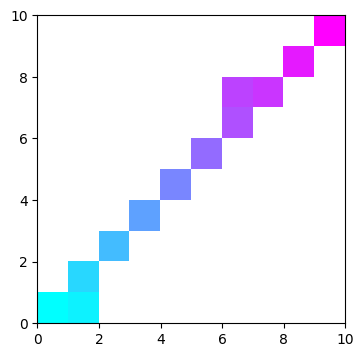

In [8]:
weights = simulate_noisy_linear()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (lower than clean diagonal due to noise)")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.4f}")

npy.plotting.plot_2d_replay(weights)
plt.show()

### 2c. Reverse trajectory

Movement from high to low coordinates. Tests that `spatiotemporal_corr` correctly returns a **negative** value when the trajectory is reversed relative to time.

spatiotemporal corr : -0.8098  (expect negative — reverse direction)
slope_x             : -0.4005  (negative slope)
slope_y             : -0.4009  (negative slope)


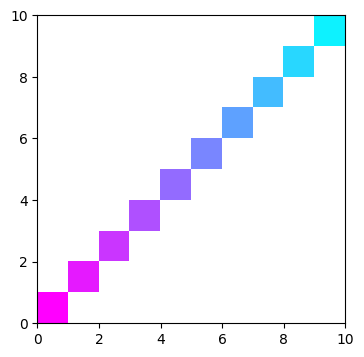

In [9]:
weights = simulate_reverse()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (expect negative — reverse direction)")
print(f"slope_x             : {slope_x:.4f}  (negative slope)")
print(f"slope_y             : {slope_y:.4f}  (negative slope)")

npy.plotting.plot_2d_replay(weights)
plt.show()

### 2d. Fragmented replay

The posterior alternates between two distant spatial clusters. This mimics ambiguous or multi-path replay. The linear fit will produce a moderate correlation even though the true trajectory is not smooth — a known limitation of the weighted correlation approach.

spatiotemporal corr : 0.1173  (moderate — linear fit across two clusters)
slope_x             : 0.0565
slope_y             : 0.0544


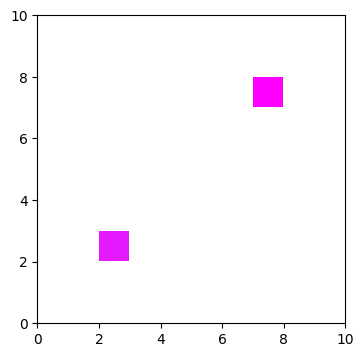

In [10]:
weights = simulate_fragmented()
corr, x_traj, y_traj, slope_x, slope_y, mean_x, mean_y = weighted_corr_2d(weights)

print(f"spatiotemporal corr : {corr:.4f}  (moderate — linear fit across two clusters)")
print(f"slope_x             : {slope_x:.4f}")
print(f"slope_y             : {slope_y:.4f}")

npy.plotting.plot_2d_replay(weights)
plt.show()

## Real data

In [11]:
# SET UP PARAMETERS FOR REAL DATA
MIN_RIP_DUR = 0.04  # minimum duration of ripple events to include in analysis (exclude short events that may reflect noise/artifacts)
MAX_RIP_DUR = 0.3  # maximum duration of ripple events to include in analysis (exclude long events that may reflect different phenomena)
N_ACTIVE_CELLS = (
    10  # minimum number of active cells in a ripple event to be included in analysis
)
POST_SLEEP_IDX = 3  # which post task is the example event in?
TASK_EPOCH = 2  # which post task is the example event in?
SPEED_THRES = 10  # running threshold to determine tuning curves
S_BINSIZE = 2  # spatial bins in tuning curve
TUNING_CURVE_SIGMA = 3
SLIDE_BY = 0.005
BIN_SIZE = 0.02


basepath = r"R:\data\latentseq\RM10\rm10_day6_20250810"
st, cm = npy.io.load_spikes(
    basepath, brainRegion="CA1", putativeCellType="Pyr|Int", remove_unstable=True
)

# load position and compute speed
position = npy.io.load_animal_behavior(basepath)
pos = nel.AnalogSignalArray(
    [position.x.values, position.y.values], timestamps=position.timestamps.values
)
speed = nel.utils.ddt_asa(pos, smooth=True, sigma=0.250, norm=True)

# load epochs and ripple events
epoch_df = npy.io.load_epoch(basepath)
beh_epochs = nel.EpochArray(epoch_df[["startTime", "stopTime"]].values)
ripples = npy.io.load_ripples_events(basepath, return_epoch_array=True)

# ripples are at least X seconds long
ripples = nel.EpochArray(
    ripples.data[(ripples.lengths >= MIN_RIP_DUR) & (ripples.lengths <= MAX_RIP_DUR)],
)
# ripples have at least X active cells
bst = npy.process.count_in_interval(st.data, ripples.starts, ripples.stops)
ripples = nel.EpochArray(
    ripples.data[(bst > 0).sum(axis=0) > N_ACTIVE_CELLS],
)


st, display(epoch_df)

,name,startTime,stopTime,environment,manipulation,behavioralParadigm,stimuli,notes,basepath
0,rm10_probe_250810_092719,0.0000,452.65915,cheeseboard,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
1,rm10_presleep_250810_094149,452.6592,6206.85435,sleep,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
2,rm10_cheeseboard1_250810_112435,6206.8544,8223.35355,cheeseboard,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
3,rm10_postsleep1_250810_120316,8223.3536,13941.93075,sleep,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
4,rm10_cheeseboard2_250810_134434,13941.9308,16500.15795,cheeseboard,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810
5,rm10_postsleep2_250810_143203,16500.1580,22562.22515,sleep,NaN,NaN,NaN,NaN,R:\data\latentseq\RM10\rm10_day6_20250810


(<SpikeTrainArray at 0x20fffa9f810: 228 units> at 20000 Hz, None)

### compute spatial tuning curves

In [12]:
spatial_maps = npy.tuning.SpatialMap(
    pos[beh_epochs[TASK_EPOCH]],
    st[beh_epochs[TASK_EPOCH]],
    s_binsize=S_BINSIZE,
    speed=speed,
    speed_thres=SPEED_THRES,
    tuning_curve_sigma=TUNING_CURVE_SIGMA,
)

### decode and score replays

* Note: Here we are not shuffling anything; this is just to demonstrate the function on real data. In practice you would want to compare these scores to a shuffle distribution to determine significance.

In [13]:
def jump_distance(posterior):
    # if single time bin return nan
    if posterior.shape[2] == 1:
        return np.nan, np.nan

    com = npy.ensemble.position_estimator(
        posterior.T,
        np.arange(posterior.shape[1]),
        np.arange(posterior.shape[0]),
        method="com",
    )
    # get spatial diff over time bins
    x_diff = np.diff(com[:, 0])
    y_diff = np.diff(com[:, 1])
    delta = np.sqrt(x_diff**2 + y_diff**2)
    max_jump = np.max(np.abs(delta))
    jump = np.sum(np.abs(delta)) / len(delta)

    return max_jump, jump

# replays from task
current_replays = ripples[beh_epochs[TASK_EPOCH]]

bin_edges = npy.process.intervals.get_overlapping_intervals(
    current_replays.start - BIN_SIZE,
    current_replays.stop + BIN_SIZE,
    BIN_SIZE,
    SLIDE_BY,
)
bin_centers = np.mean(bin_edges, axis=1)

bst = npy.process.count_in_interval(
    st.data,
    bin_edges[:, 0],
    bin_edges[:, 1],
)

# find which bin belongs to which ripple
within_ripple_idx, within_ripple_ind = npy.process.in_intervals(
    bin_centers, current_replays.data, return_interval=True
)
ripple_index = within_ripple_ind[within_ripple_idx]
unique_ripples = np.unique(ripple_index).astype(int)
# remake current_replays in case of non unique ripples
current_replays = nel.EpochArray(current_replays.data[unique_ripples, :])

# decode replays
posterior_prob = npy.ensemble.decoding.bayesian.decode_with_prior_fallback(
    bst[:, within_ripple_idx].T,
    spatial_maps.ratemap.T,
    spatial_maps.occupancy.T,
    BIN_SIZE,
    uniform_prior=True,
).T
good_time_bins = np.sum(bst[:, within_ripple_idx], axis=0) > 0

max_jump = []
jump = []
weighted_corr = []
slope_x = []
slope_y = []
mean_x = []
mean_y = []
for rid in unique_ripples:
    posterior_ripple = posterior_prob[:, :, ripple_index == rid]
    current_ripple_idx = ripple_index == rid

    max_jump_, jump_ = jump_distance(
        posterior_ripple[..., good_time_bins[current_ripple_idx]]
    )
    (
        weighted_correlation_coefficient,
        x_trajectory,
        y_trajectory,
        slope_x_,
        slope_y_,
        mean_x_,
        mean_y_,
    ) = npy.ensemble.weighted_corr_2d(
        posterior_ripple,
        x_coords=spatial_maps.xbin_centers,
        y_coords=spatial_maps.ybin_centers,
        time_coords=np.arange(posterior_ripple.shape[2]) * SLIDE_BY,
    )

    max_jump.append(max_jump_)
    jump.append(jump_)
    weighted_corr.append(weighted_correlation_coefficient)
    slope_x.append(slope_x_)
    slope_y.append(slope_y_)
    mean_x.append(mean_x_)
    mean_y.append(mean_y_)

weighted_corr = np.array(weighted_corr)
jump = np.array(jump) * S_BINSIZE
max_jump = np.array(max_jump) * S_BINSIZE
slope_x = np.array(slope_x)
slope_y = np.array(slope_y)
mean_x = np.array(mean_x)
mean_y = np.array(mean_y)

#### package into dataframe for later saving and analysis

In [14]:
potential_replays = pd.DataFrame()
potential_replays["ripple_index"] = unique_ripples
potential_replays["weighted_corr"] = weighted_corr
potential_replays["weighted_corr_abs"] = np.abs(weighted_corr)
potential_replays["jump"] = jump
potential_replays["max_jump"] = max_jump
potential_replays["slope_x"] = slope_x
potential_replays["slope_y"] = slope_y
potential_replays["mean_x"] = mean_x
potential_replays["mean_y"] = mean_y

potential_replays.query("jump < 12").sort_values("weighted_corr_abs", ascending=False)

,ripple_index,weighted_corr,weighted_corr_abs,jump,max_jump,slope_x,slope_y,mean_x,mean_y
155,155,-0.912965,0.912965,5.048513,26.450355,497.622576,-735.002205,48.925101,73.781679
182,182,-0.906190,0.906190,5.836934,53.620001,-1292.102394,-463.456814,111.743988,81.464158
615,615,-0.905749,0.905749,2.325517,6.799726,307.902075,-447.962559,54.511916,65.698982
309,309,0.888116,0.888116,5.755355,35.515835,-933.704765,769.558976,103.065618,109.256980
518,518,-0.863428,0.863428,3.382480,18.033893,440.020776,-647.446706,55.130015,65.516742
...,...,...,...,...,...,...,...,...,...
392,392,0.041132,0.041132,4.208392,14.650454,15.394767,26.622957,125.622804,88.886318
244,244,-0.039981,0.039981,9.985856,25.520723,52.566586,-48.227792,156.648520,93.369748
159,159,0.039813,0.039813,4.430573,17.412706,-17.686837,20.846424,149.691172,98.973949
43,43,-0.039685,0.039685,5.420109,18.517353,13.712769,-12.811157,157.386250,95.613318


### plot potential replays and fit lines

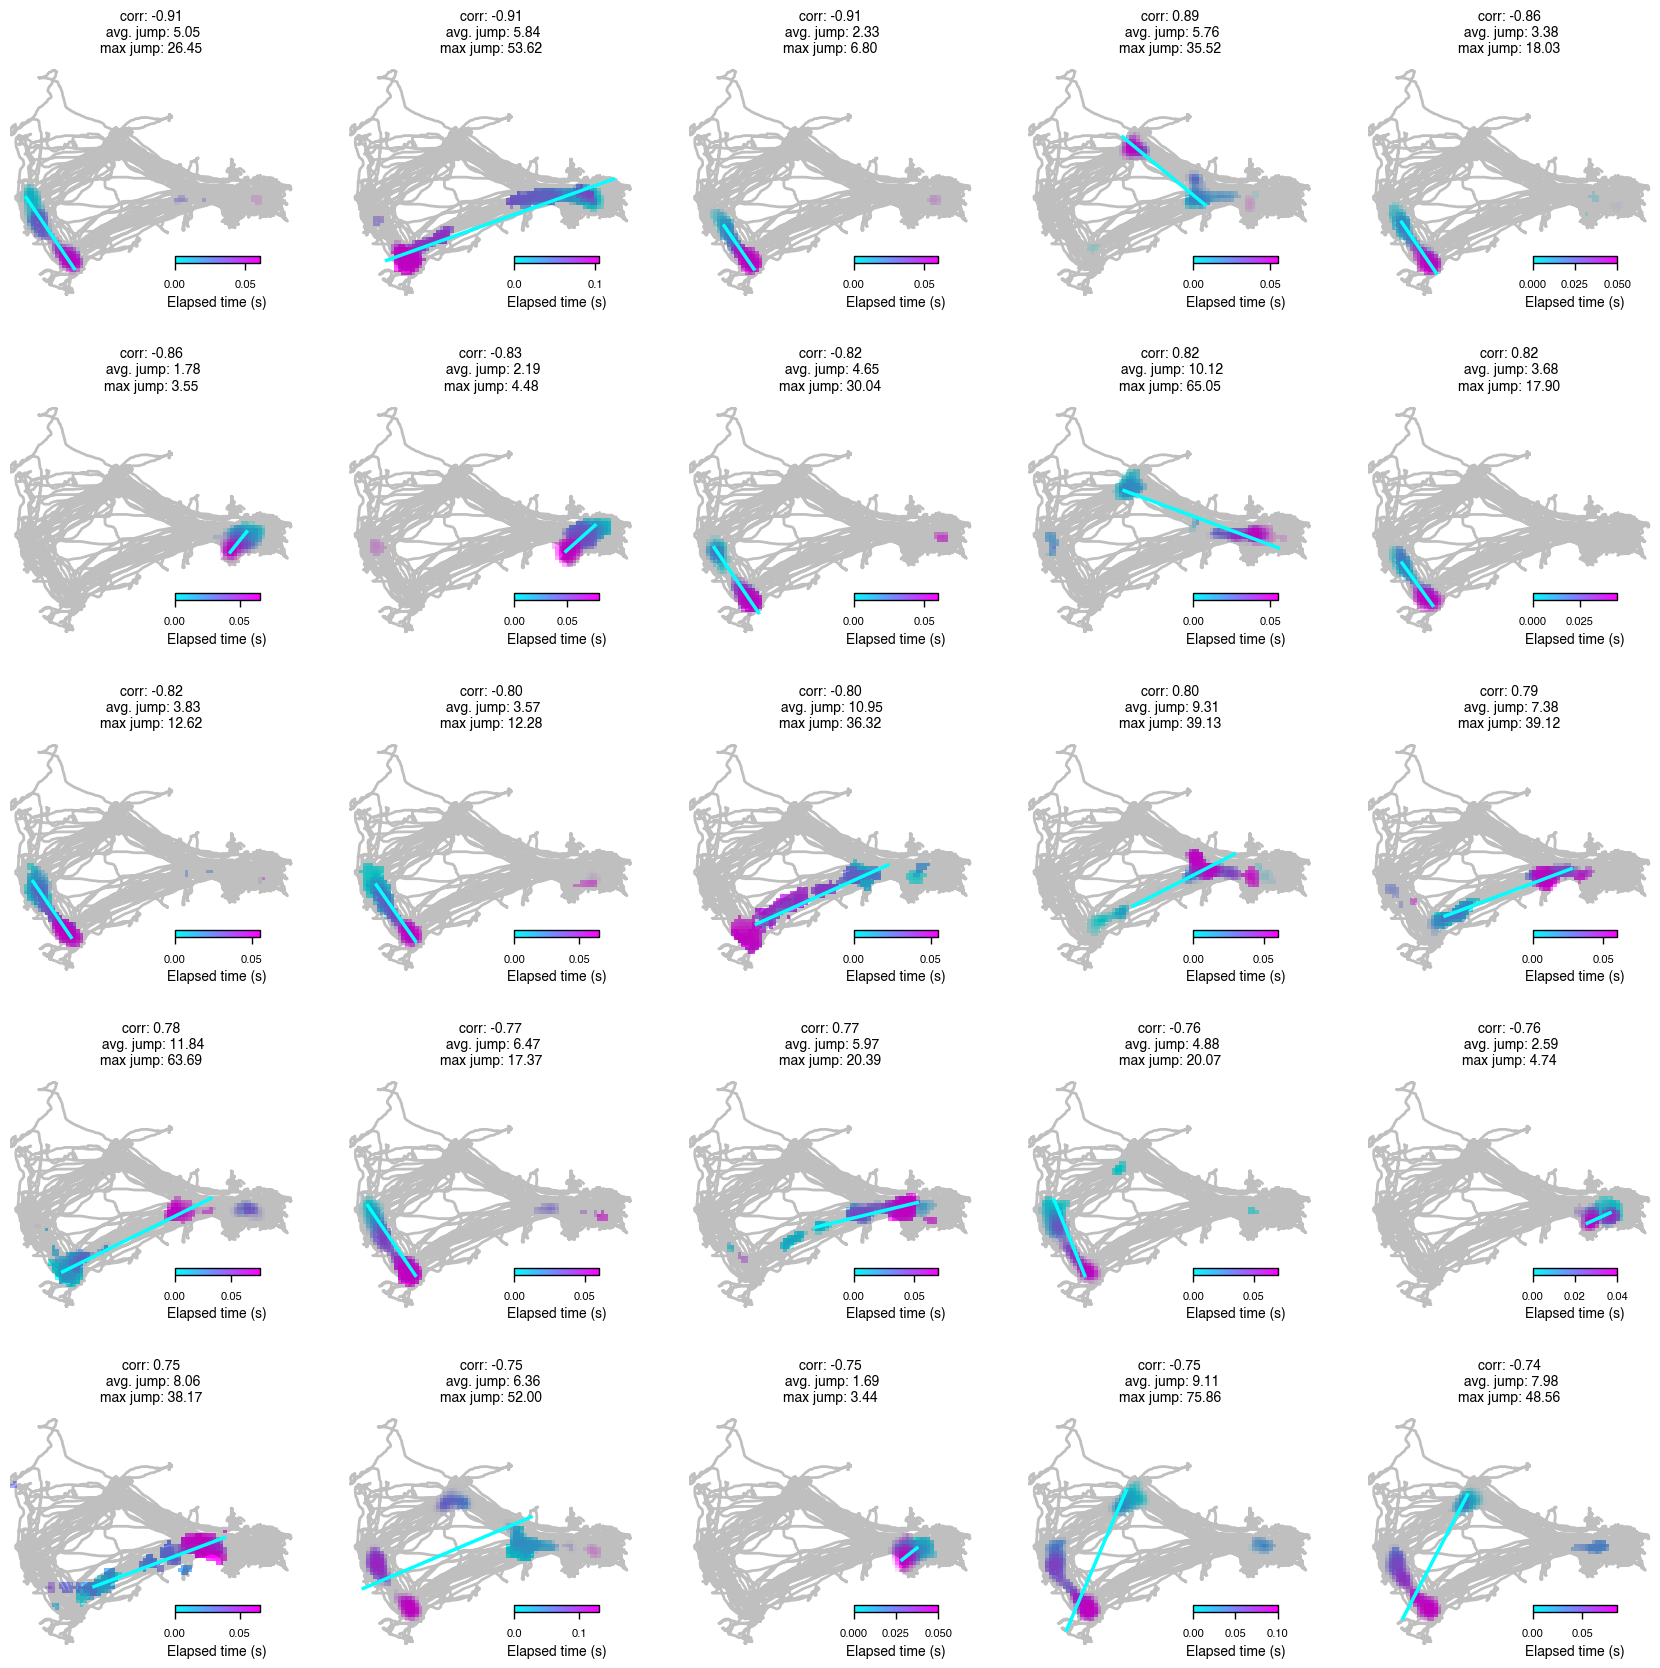

In [15]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

npy.plotting.set_plotting_defaults()
slide_by = 0.005
bin_size = 0.02
x, y = pos[beh_epochs[TASK_EPOCH]].data

fig, ax = plt.subplots(
    5, 5, figsize=npy.plotting.set_size("nature_double", fraction=1.5, ratio=1), dpi=200
)
ax = ax.flatten()
ripple_index_potential = (
    potential_replays.query("jump < 12")
    .sort_values("weighted_corr_abs", ascending=False)
    .ripple_index.values
)

for i, rid in enumerate(ripple_index_potential[:25]):
    posterior_ripple = posterior_prob[:, :, ripple_index == rid]
    ax[i].plot(x, y, color="k", alpha=0.25, zorder=2)

    npy.plotting.plot_2d_replay(
        posterior_ripple,
        extent=[
            spatial_maps.bins[0][0],
            spatial_maps.bins[0][-1],
            spatial_maps.bins[1][0],
            spatial_maps.bins[1][-1],
        ],
        saturation=5,
        ax=ax[i],
    )

    # plot fit line
    t = np.arange(posterior_ripple.shape[2], dtype=float) * SLIDE_BY
    t_centered = t - t.mean()
    x_fit = mean_x[rid] + slope_x[rid] * t_centered
    y_fit = mean_y[rid] + slope_y[rid] * t_centered
    ax[i].plot(x_fit, y_fit, color="cyan", lw=1.25, zorder=4)

    ax[i].set_title(
        f"corr: {weighted_corr[rid]:.2f}\n avg. jump: {jump[rid]:.2f}\nmax jump: {max_jump[rid]:.2f}",
        fontsize=5,
    )

    # Colorbar
    cmap = matplotlib.colormaps.get_cmap("cool").resampled(posterior_prob.shape[2])
    norm = colors.Normalize(vmin=0, vmax=posterior_ripple.shape[2] * SLIDE_BY)
    sm = mpl_cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cax = inset_axes(ax[i], width="30%", height="3%", loc="lower right", borderpad=2)
    cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cax.xaxis.set_label_position("bottom")
    cax.set_xlabel("Elapsed time (s)", fontsize=5, labelpad=2)
    cbar.ax.tick_params(labelsize=4)

    ax[i].axis("off")
plt.show()

## Summary

| Scenario | Expected corr | Notes |
|---|---|---|
| Only Y moves | ~+0.86 | corr_x degenerate, corr_y only |
| Only X moves | ~+0.86 | corr_y degenerate, corr_x only |
| No movement | ~0 | noise floor |
| Both axes (diagonal) | ~+0.81 | RMS of corr_x and corr_y |
| Curved arc | attenuated | nonlinear Y cancels in linear fit |
| Noisy linear | moderate | signal diluted by decode uncertainty |
| Reverse diagonal | negative | sign correctly flipped |
| Fragmented | moderate | linear fit spans two clusters |